In [ ]:
# conda create --prefix ./geoenvs -c conda-forge python=3.11 dask opencv pygeos spatialpandas datashader geopandas pandas matplotlib geopy pyarrow osmnx pyrosm osmium-tool flask flask-cors

In [1]:
import pandas as pd
import geopandas as gpd
import spatialpandas as sp
import datashader as ds
import numpy as np
import pyarrow as pa
import matplotlib.pyplot as plt
import pygeos
import math
import os
import time
import warnings
import cv2
import glob
import dask

from shapely.geometry import box
from pyproj import Transformer
from spatialpandas import GeoDataFrame

import datashader as ds
from datashader.core import bypixel

c:\Users\qshah\Documents\Fall 2026\scout\backend\envs\Lib\site-packages\dask\dataframe\_pyarrow_compat.py:15: FutureWarning: Minimal version of pyarrow will soon be increased to 14.0.1. You are using 12.0.1. Please consider upgrading.
  warnings.warn(


In [2]:
transformer = Transformer.from_crs(3395, 4326)
invtransformer = Transformer.from_crs(4326,3395)

In [3]:
def get_flat_coords_offset_arrays(arr):
    """
    Version for MultiPolygon data
    """
    # explode/flatten the MultiPolygons
    arr_flat, part_indices = pygeos.get_parts(arr, return_index=True)
    # the offsets into the multipolygon parts
    offsets1 = np.insert(np.bincount(part_indices).cumsum(), 0, 0)

    # explode/flatten the Polygons into Rings
    arr_flat2, ring_indices = pygeos.geometry.get_rings(arr_flat, return_index=True)
    # the offsets into the exterior/interior rings of the multipolygon parts 
    offsets2 = np.insert(np.bincount(ring_indices).cumsum(), 0, 0)

    # the coords and offsets into the coordinates of the rings
    coords, indices = pygeos.get_coordinates(arr_flat2, return_index=True)
    offsets3 = np.insert(np.bincount(indices).cumsum(), 0, 0)
    
    return coords, offsets1, offsets2, offsets3

def spatialpandas_from_pygeos(arr):
    coords, offsets1, offsets2, offsets3 = get_flat_coords_offset_arrays(arr)
    coords_flat = coords.ravel()
    offsets3 *= 2
    
    # create a pyarrow array from this
    _parr3 = pa.ListArray.from_arrays(pa.array(offsets3), pa.array(coords_flat))
    _parr2 = pa.ListArray.from_arrays(pa.array(offsets2), _parr3)
    parr = pa.ListArray.from_arrays(pa.array(offsets1), _parr2)
    
    return sp.geometry.MultiPolygonArray(parr)

def polygons(self, source, geometry, agg=None):
    from datashader.glyphs import PolygonGeom
    from datashader.reductions import any as any_rdn
    from spatialpandas import GeoDataFrame
    from spatialpandas.dask import DaskGeoDataFrame
    if isinstance(source, DaskGeoDataFrame):
        # Downselect partitions to those that may contain polygons in viewport
        x_range = self.x_range if self.x_range is not None else (None, None)
        y_range = self.y_range if self.y_range is not None else (None, None)
        source = source.cx_partitions[slice(*x_range), slice(*y_range)]
    elif isinstance(source, gpd.GeoDataFrame):
        # Downselect actual rows to those for which the polygon is in viewport
        x_range = self.x_range if self.x_range is not None else (None, None)
        y_range = self.y_range if self.y_range is not None else (None, None)
        source = source.cx[slice(*x_range), slice(*y_range)]
        # Convert the subset to ragged array format of spatialpandas
        geometries = spatialpandas_from_pygeos(source.geometry.array.data)
        source = pd.DataFrame(source)
        source["geometry"] = geometries
    elif not isinstance(source, GeoDataFrame):
        raise ValueError(
            "source must be an instance of spatialpandas.GeoDataFrame or \n"
            "spatialpandas.dask.DaskGeoDataFrame.\n"
            "  Received value of type {typ}".format(typ=type(source)))

    if agg is None:
        agg = any_rdn()
    glyph = PolygonGeom(geometry)
    return bypixel(source, self, glyph, agg)

ds.Canvas.polygons = polygons
cvs = ds.Canvas(plot_width=256, plot_height=256)

In [4]:
def deg2num(lat_deg, lon_deg, zoom):
    lat_rad = math.radians(lat_deg)
    n = 2.0 ** zoom
    xtile = ((lon_deg + 180.0) / 360.0 * n)
    ytile = ((1.0 - math.asinh(math.tan(lat_rad)) / math.pi) / 2.0 * n)
    return (xtile, ytile)

def num2deg(xtile, ytile, zoom):
    n = 2.0 ** zoom
    lon_deg = xtile / n * 360.0 - 180.0
    lat_rad = math.atan(math.sinh(math.pi * (1 - 2 * ytile / n)))
    lat_deg = math.degrees(lat_rad)
    return (lat_deg, lon_deg)

In [5]:
def elevation(filtered, bbox):
    proxy = pd.DataFrame({'height': 0, 'geometry': bbox}, index=[len(filtered)])
    proxy = gpd.GeoDataFrame(proxy)
    proxy.crs = '3395'

    clipped = gpd.clip(filtered, proxy)
    intersection = pd.concat([proxy, clipped], ignore_index=True)
    intersection = intersection[intersection.geom_type.isin(['Polygon', 'MultiPolygon'])]
    if len(intersection) > 0:
        intersection = sp.GeoDataFrame(intersection)
        values = cvs.polygons(intersection, geometry='geometry', agg=ds.max("height"))
    else:
        values = np.zeros((256,256))
    values = np.flipud(values)
    return values

def create_image(values, i, j, zoom, max_height, outputfolder):
    filename = '%s/%d/%d/%d.png'%(outputfolder,zoom,i,j)
    success = cv2.imwrite(filename, 255.0 * (values / max_height))
    if not success:
        raise Exception("Could not write image")
        
@dask.delayed
def compute_tile(gdf, i, j, zoom, max_height, outputfolder):
    bb0 = num2deg(i,j,zoom)
    bb1 = num2deg(i+1,j+1,zoom)
    bb0 = invtransformer.transform(bb0[0],bb0[1])
    bb1 = invtransformer.transform(bb1[0],bb1[1])
    bbox = box(bb0[0],bb0[1],bb1[0],bb1[1])
#     filtered = gdf.cx[bb0[0]:bb1[0],bb0[1]:bb1[1]]
    filtered = gdf.loc[gdf.sindex.intersection(bbox.bounds)]
    
    if len(filtered) > 0:
        values = elevation(filtered, bbox)
        create_image(values, i, j, zoom, max_height, outputfolder)
        
def compute_all(gdf, zoom, max_height, outputfolder):
    bounds = gdf.total_bounds
    lat0,lng0 = transformer.transform(bounds[0],bounds[1])
    lat1,lng1 = transformer.transform(bounds[2],bounds[3])
    coord0 = deg2num(lat0,lng0,zoom)
    coord1 = deg2num(lat1,lng1,zoom)
    bottomleft = [min(coord0[0],coord1[0]),min(coord0[1],coord1[1])]
    topright = [max(coord0[0],coord1[0]),max(coord0[1],coord1[1])]
    
    # Create folders (serial)
    for i in range(math.floor(bottomleft[0]),math.ceil(topright[0])):
        folder = '%s/%d/%d/'%(outputfolder,zoom,i)
        if not os.path.exists(folder):
            os.makedirs(folder)
    
    delayed = []
    for i in range(math.floor(bottomleft[0]),math.ceil(topright[0])):
        for j in range(math.floor(bottomleft[1]),math.ceil(topright[1])):
            ddelayed = compute_tile(gdf, i, j, zoom, max_height, outputfolder)
            delayed.append(ddelayed)
    dask.compute(*delayed)

In [6]:
def elevation(filtered, bbox):
    proxy = pd.DataFrame({'height': 0, 'geometry': bbox}, index=[len(filtered)])
    proxy = gpd.GeoDataFrame(proxy)
    proxy.crs = '3395'

    clipped = gpd.clip(filtered, proxy)
    intersection = pd.concat([proxy, clipped], ignore_index=True)
    intersection = intersection[intersection.geom_type.isin(['Polygon', 'MultiPolygon'])]
    if len(intersection) > 0:
        intersection = sp.GeoDataFrame(intersection)
        values = cvs.polygons(intersection, geometry='geometry', agg=ds.max("height"))
    else:
        values = np.zeros((256,256))
    values = np.flipud(values)
    return values

def create_image(values, i, j, zoom, max_height, outputfolder):
    filename = '%s/%d_%d_%d.png'%(outputfolder,zoom,i,j)
    success = cv2.imwrite(filename, 255.0 * (values / max_height))
    if not success:
        raise Exception("Could not write image")
        
# @dask.delayed
def compute_tile(gdf, i, j, zoom, max_height, outputfolder):
    bb0 = num2deg(i,j,zoom)
    bb1 = num2deg(i+1,j+1,zoom)
    bb0 = invtransformer.transform(bb0[0],bb0[1])
    bb1 = invtransformer.transform(bb1[0],bb1[1])
    bbox = box(bb0[0],bb0[1],bb1[0],bb1[1])
#     filtered = gdf.cx[bb0[0]:bb1[0],bb0[1]:bb1[1]]
    filtered = gdf.loc[gdf.sindex.intersection(bbox.bounds)]
    
    if len(filtered) > 0:
        values = elevation(filtered, bbox)
        create_image(values, i, j, zoom, max_height, outputfolder)

    else:
        print(f"No data for tile {zoom}/{i}/{j}")

In [7]:
# Read a GeoJSON file
gdf = gpd.read_file("./data/served/baselayer-0_buildings.geojson")
min_lon, min_lat, max_lon, max_lat = gdf.total_bounds
outputfolder = "./data/served/baselayer-0_buildings_raster/"

os.makedirs(outputfolder, exist_ok=True)

z = 16

# (top-left)
x0, y0 = deg2num(max_lat, min_lon, z)
# (bottom-right)
x1, y1 = deg2num(min_lat, max_lon, z)

# Tile index ranges (inclusive)
min_x = math.floor(x0)   # left
max_x = math.ceil(x1)    # right
min_y = math.floor(y0)   # top
max_y = math.ceil(y1)    # bottom

# change gdf crs to 3395
gdf = gdf.to_crs(epsg=3395)

delayed = []
for i in range(min_x, max_x + 1):
    for j in range(min_y, max_y + 1):
        ddelayed = compute_tile(gdf, i, j, z, 550, outputfolder)
        delayed.append(ddelayed)
    
dask.compute(*delayed);

No data for tile 16/16812/24359
No data for tile 16/16812/24360
No data for tile 16/16813/24359
No data for tile 16/16813/24360
No data for tile 16/16814/24360
No data for tile 16/16815/24360
No data for tile 16/16816/24359
No data for tile 16/16816/24360
No data for tile 16/16817/24358
No data for tile 16/16817/24359
No data for tile 16/16817/24360
No data for tile 16/16818/24353
No data for tile 16/16818/24354
No data for tile 16/16818/24355
No data for tile 16/16818/24356
No data for tile 16/16818/24357
No data for tile 16/16818/24358
No data for tile 16/16818/24359
No data for tile 16/16818/24360


Detected tile size: 256x256


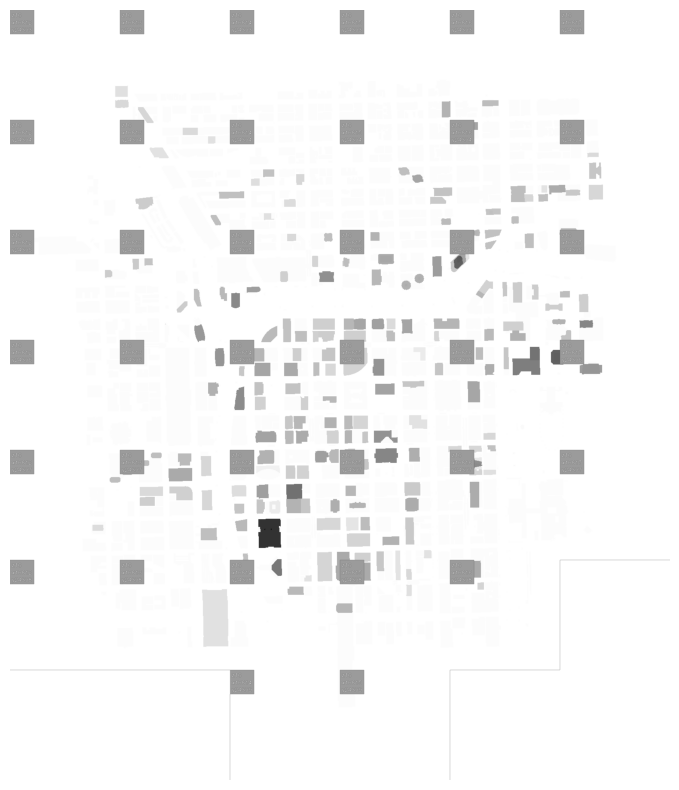

Saved mosaic to ./data/served/baselayer-0_buildings_raster\mosaic_inverted_labeled.png


In [10]:
import os
import glob
from PIL import Image, ImageOps, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# ---- config ----
tile_dir = "./data/served/baselayer-0_buildings_raster"
z = 16
tile_pattern = os.path.join(tile_dir, f"{z}_*_*.png")

# ---- collect tiles ----
files = glob.glob(tile_pattern)
if not files:
    raise RuntimeError(f"No tiles found matching pattern: {tile_pattern}")

tiles = []
xs, ys = set(), set()

for path in files:
    name = os.path.basename(path)
    if not name.lower().endswith(".png"):
        continue

    stem = name[:-4]  # strip .png
    parts = stem.split("_")
    if len(parts) != 3:
        continue

    z_str, x_str, y_str = parts
    try:
        if int(z_str) != z:
            continue
        x = int(x_str)
        y = int(y_str)
    except ValueError:
        continue

    xs.add(x)
    ys.add(y)
    tiles.append((x, y, path))

if not tiles:
    raise RuntimeError("No valid tile filenames parsed (expected z_x_y.png).")

xs = sorted(xs)
ys = sorted(ys)

# ---- infer tile size ----
sample = Image.open(tiles[0][2])
tile_w, tile_h = sample.size
print(f"Detected tile size: {tile_w}x{tile_h}")

# ---- build grid index ----
x_index = {x: i for i, x in enumerate(xs)}
y_index = {y: i for i, y in enumerate(ys)}

# ---- prepare mosaic canvas ----
mosaic_w = len(xs) * tile_w
mosaic_h = len(ys) * tile_h
mosaic = Image.new("RGBA", (mosaic_w, mosaic_h))

# ---- font for labels ----
try:
    # tweak if arial.ttf isn't available on your system
    font = ImageFont.truetype("arial.ttf", 14)
except Exception:
    font = ImageFont.load_default()

# ---- process tiles: invert + label + paste ----
for x, y, path in tiles:
    img = Image.open(path).convert("RGBA")

    # Invert RGB channels, keep alpha
    r, g, b, a = img.split()
    rgb_inv = ImageOps.invert(Image.merge("RGB", (r, g, b)))
    r_i, g_i, b_i = rgb_inv.split()
    img_inv = Image.merge("RGBA", (r_i, g_i, b_i, a))

    # Draw z/x/y label
    draw = ImageDraw.Draw(img_inv)
    label = f"z{z}\nx{x}\ny{y}"
    padding = 4

    # Use multiline_textbbox to get label box size
    bbox = draw.multiline_textbbox((0, 0), label, font=font)
    box_w = bbox[2] - bbox[0]
    box_h = bbox[3] - bbox[1]

    # Background box for readability
    box_coords = [
        0,
        0,
        box_w + 2 * padding,
        box_h + 2 * padding,
    ]
    draw.rectangle(box_coords, fill=(0, 0, 0, 160))

    # White text on top
    draw.multiline_text(
        (padding, padding),
        label,
        font=font,
        fill=(255, 255, 255, 255),
    )

    # Paste into mosaic at grid position
    ix = x_index[x]
    iy = y_index[y]
    px = ix * tile_w
    py = iy * tile_h
    mosaic.paste(img_inv, (px, py), img_inv)

# ---- show mosaic ----
plt.figure(figsize=(8, 8))
plt.imshow(mosaic)
plt.axis("off")
plt.tight_layout()
plt.show()

# ---- optional: save result ----
out_path = os.path.join(tile_dir, "mosaic_inverted_labeled.png")
mosaic.save(out_path)
print(f"Saved mosaic to {out_path}")
